# 날씨 및 공간 데이터 통합 EDA와 상호작용 가설 검증

본 노트북은 전국 산불 위치별 공간 정보 캐시 데이터(`fire_spatial_features.csv`)와 기상청 일자별 날씨 데이터(`날씨데이터_일자별_전국산불.csv`)를 병합하여, **날씨(기상) 요인과 공간(지형 및 시설물 접근성) 요인의 복합적 상호작용**이 산불 진화 시간 및 피해 규모에 미치는 영향력을 통계적으로 검증하고 시각화합니다.

---

## 분석 구성
1. **상호작용 가설 검증 (Section 1)**
   - 가설 1.1: 영동권 × 봄철 × 강풍 (풍속 대역별 12h 이상 진화 지연율)
   - 가설 1.2: 영동권 × 서/남서 사면 × W/SW 풍향 (풍향과 사면 방향 일치 효과)
   - 가설 1.3: 영동권 × 서/남서 사면 × 접근취약 × 기상 피크 (4대 취약 요인의 누적 결합)
   - 가설 1.4: 강풍 × 원격제어 불가능 (기상 피크 하에 예방설비 기능성 유무)
   - 가설 1.5: 저습/실효습도 × 접근취약 (건조 기류와 접근 인프라 제약의 2-way 시너지)
   
2. **날씨와 공간 결합 심화 EDA (Section 2)**
   - 2.1 고도(Elevation) vs 대기 건조도 (VPD & 이슬점 격차)
   - 2.2 경사도(Slope) vs 평균 풍속
   - 2.3 악기상 조건 × 접근 부담 시너지 효과 (강원도 기준 히트맵 분석)



## 라이브러리 및 Matplotlib 한글 폰트 설정

Windows 환경의 기본 한글 폰트인 **맑은 고딕(Malgun Gothic)**을 직접 Matplotlib 폰트 매니저에 등록하고, Seaborn 테마와 충돌하지 않도록 조화롭게 설정합니다.



In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

# 1. Matplotlib 한글 폰트 설정 (Windows 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])



현재 matplotlib font.family: ['Malgun Gothic']


## 데이터 로드 및 병합

- **공간 데이터**: `fire_spatial_features.csv` (25,036건)
- **날씨 데이터**: `날씨데이터_일자별_전국산불.csv` (발생일 및 과거 1일)
- **병합 키**: `fire_id` 와 `산불아이디`



In [2]:
# 데이터 로드
spatial = pd.read_csv("d:/farm-system-public-02/jsw/EDA/fire_spatial_features.csv")
daily = pd.read_csv("d:/farm-system-public-02/data/날씨데이터/날씨데이터_일자별_전국산불.csv")

# 발생일과 과거1일 날씨 분리
day_active = daily[daily["날짜구분"] == "발생일"].copy()
day_past = daily[daily["날짜구분"] == "과거1일"].copy()

# 컬럼 리네임
day_active = day_active.rename(columns={
    "평균 풍속": "wind_active",
    "최소 상대습도": "humid_active",
    "최대 순간풍속": "gust_active",
    "평균 기온": "temp_active",
    "평균 상대습도": "rh_mean_active",
    "최대 순간 풍속 풍향": "gust_dir_active",
    "평균 현지기압": "press_active",
    "진화소요시간시": "duration_daily",
    "평균 이슬점온도": "dew_active"
})

day_past = day_past.rename(columns={
    "평균 풍속": "wind_past",
    "최소 상대습도": "humid_past"
})

# 날씨 데이터 조인
weather_merged = pd.merge(
    day_active[["산불아이디", "wind_active", "humid_active", "gust_active", "temp_active", "rh_mean_active", "gust_dir_active", "press_active", "duration_daily", "dew_active"]],
    day_past[["산불아이디", "wind_past", "humid_past"]],
    on="산불아이디",
    how="inner"
)

# 실효습도(r=0.04 최적 감쇄) 및 VPD, 이슬점격차 계산
weather_merged["effective_humidity"] = 0.96 * (weather_merged["humid_active"] + 0.04 * weather_merged["humid_past"])
temp_day = weather_merged["temp_active"]
rh_day = weather_merged["rh_mean_active"]
es_day = 6.1078 * np.exp((17.27 * temp_day) / (temp_day + 237.3))
weather_merged["VPD"] = es_day * (1 - rh_day / 100)
weather_merged["dew_gap"] = weather_merged["temp_active"] - weather_merged["dew_active"]

# 공간 데이터 병합
df_merged = pd.merge(
    spatial,
    weather_merged,
    left_on="fire_id",
    right_on="산불아이디",
    how="inner"
)

# 타깃 변수 수치화 및 결측 데이터 마스킹 (보간 없음)
df_merged['_suppression_hours'] = pd.to_numeric(df_merged['duration_daily'], errors='coerce')
df_merged['_suppression_valid'] = (df_merged['_suppression_hours'] > 0) & df_merged['_suppression_hours'].notna()
df_merged['_large_fire_12h'] = np.where(df_merged['_suppression_valid'], df_merged['_suppression_hours'] >= 12, np.nan)
df_merged['_damage_ha'] = pd.to_numeric(df_merged.get('피해면적(ha)', np.nan), errors='coerce')
df_merged['_log_damage_ha'] = np.log1p(df_merged['_damage_ha'].clip(lower=0))

print("통합 데이터셋 크기:", df_merged.shape)
print("진화소요시간 유효 표본 수 N:", df_merged['_suppression_valid'].sum())



통합 데이터셋 크기: (25036, 80)
진화소요시간 유효 표본 수 N: 6439


In [3]:
# 8방위 변환 및 공간 지수 전처리
# 영동 해안권 매핑
yeongdong_districts = ["강릉시", "속초시", "동해시", "삼척시", "태백시", "고성군", "양양군", 
                        "강릉", "속초", "동해", "삼척", "태백", "고성", "양양"]
df_merged["sub_region"] = df_merged["발생지역시군구명"].apply(
    lambda x: "영동 해안" if x in yeongdong_districts else "영서 내륙"
)
df_merged['is_yeongdong'] = df_merged['sub_region'] == '영동 해안'

# 사면 8방위 사면각 계산
df_merged['aspect_deg'] = np.degrees(np.arctan2(df_merged['사면방향_sin'], df_merged['사면방향_cos'])) % 360
aspect_bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
aspect_labels = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)', '북(N)']
df_merged['aspect_8dir'] = pd.cut(df_merged['aspect_deg'], bins=aspect_bins, labels=aspect_labels, include_lowest=True, ordered=False).astype(str)
df_merged['west_southwest_aspect'] = df_merged['aspect_8dir'].isin(['서(W)', '남서(SW)'])

# 풍향 8방위 범주화
def deg_to_8direction(deg):
    if pd.isna(deg):
        return np.nan
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int((deg + 22.5) / 45) % 8
    return directions[idx]
df_merged['wind_dir_8dir'] = df_merged['gust_dir_active'].apply(deg_to_8direction)
df_merged['west_southwest_wind'] = df_merged['wind_dir_8dir'].isin(['W', 'SW'])

# 접근성 등급화 (전국 기준)
dist_vars = ['nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_facility_dist_km', 'nearest_trail_dist_km', 'nearest_road_dist_km']
for col in dist_vars:
    df_merged[f'{col}_pct'] = df_merged[col].rank(pct=True)
df_merged['access_burden_index'] = df_merged[[f'{c}_pct' for c in dist_vars]].mean(axis=1)
df_merged['access_grade'] = pd.qcut(df_merged['access_burden_index'], q=[0, 1/3, 2/3, 1], labels=['접근 우수', '접근 보통', '접근 취약'], duplicates='drop')
df_merged['access_vulnerable_nat'] = df_merged['access_grade'].astype(str).eq('접근 취약')
df_merged['remote_unavailable'] = df_merged['nearest_facility_remote'].astype(str).eq('불가능')

# 강원도 전용 서브셋
gw = df_merged[df_merged['is_gangwon'] == True].copy()
for col in dist_vars:
    gw[f'{col}_gw_pct'] = gw[col].rank(pct=True)
gw['access_burden_gw'] = gw[[f'{c}_gw_pct' for c in dist_vars]].mean(axis=1)
gw['access_grade_gw'] = pd.qcut(gw['access_burden_gw'], q=[0, 1/3, 2/3, 1], labels=['접근 우수', '접근 보통', '접근 취약'], duplicates='drop')
gw['access_vulnerable'] = gw['access_grade_gw'].astype(str).eq('접근 취약')



## 1. 상호작용 가설 검증 (Section 1)

앞서 세운 5가지 우선 상호작용 가설에 대해 통계량을 측정하고 시각화합니다.



### 가설 1.1: 영동권 × 봄철 × 강풍
- **가설**: 봄철(3~5월) 영동 해안권에서 풍속이 높을수록 대형 산불(12h 이상 진화) 비율이 기하급수적으로 가속되는가?



  wind_bin  count      mean
0  0-3 m/s     56  0.035714
1  3-5 m/s     57  0.070175
2   >5 m/s     24  0.333333


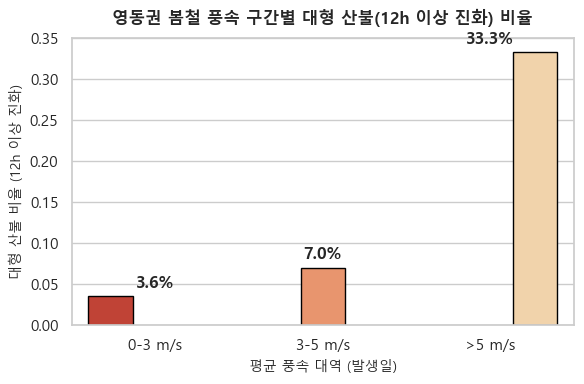

In [4]:
# 데이터 필터링
gw_spring = gw[gw['월'].isin([3, 4, 5])].copy()
yd_spring = gw_spring[gw_spring['sub_region'] == '영동 해안'].copy()
yd_spring_valid = yd_spring[yd_spring['_suppression_valid']].copy()

# 풍속 대역 범주화
yd_spring_valid['wind_bin'] = pd.cut(
    yd_spring_valid['wind_active'], 
    bins=[0, 3.0, 5.0, np.inf], 
    labels=['0-3 m/s', '3-5 m/s', '>5 m/s']
)

# 집계 및 출력
hyp1_data = yd_spring_valid.groupby('wind_bin', observed=False)['_large_fire_12h'].agg(['count', 'mean']).reset_index()
print(hyp1_data)

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(data=hyp1_data, x='wind_bin', y='mean', palette='OrRd_r', edgecolor='black', hue='wind_bin', legend=False)
plt.title('영동권 봄철 풍속 구간별 대형 산불(12h 이상 진화) 비율', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('평균 풍속 대역 (발생일)', fontsize=10)
plt.ylabel('대형 산불 비율 (12h 이상 진화)', fontsize=10)
plt.ylim(0, 0.35)
for idx, row in hyp1_data.iterrows():
    plt.text(idx, row['mean'] + 0.01, f"{row['mean']*100:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



**가설 1.1 검증 결과 및 해석**:

영동권 봄철 산불 중 진화소요시간이 유효한 표본은 137건이다. 평균 풍속 0~3m/s 구간은 56건 중 12시간 이상 진화 비율이 3.57%, 3~5m/s 구간은 57건 중 7.02%였고, 5m/s 초과 구간은 24건 중 33.33%로 크게 상승했다.

따라서 영동권 봄철에는 평균 풍속 5m/s 초과 구간에서 장시간 진화 위험이 뚜렷하게 커지는 신호가 있다. 다만 5m/s 초과 구간의 유효 표본은 24건으로 작기 때문에, 이 값을 고정 임계값으로 단정하기보다는 강풍 상위 구간에서 대형화 위험이 급격히 커질 수 있다는 후보 규칙으로 보는 것이 적절하다.


### 가설 1.2: 영동권 × 서/남서 사면 × W/SW 풍향
- **가설**: 영동 해안 지방에서 산불 발화 사면(Aspect) 방향과 당일 최대순간풍속 풍향이 서/남서(W/SW)로 일치할 때, 지형적 가속 효과(양간지풍 바람길 정렬)로 인해 피해면적 및 진화시간이 크게 악화되는가?



                   total_N  valid_N  mean_duration  large_12h_rate  mean_damage  median_damage
aspect_wind_match                                                                             
False                 1238      221       3.189593        0.072398     6.848821            0.0
True                   371       48       4.920833        0.125000    47.692615            0.0


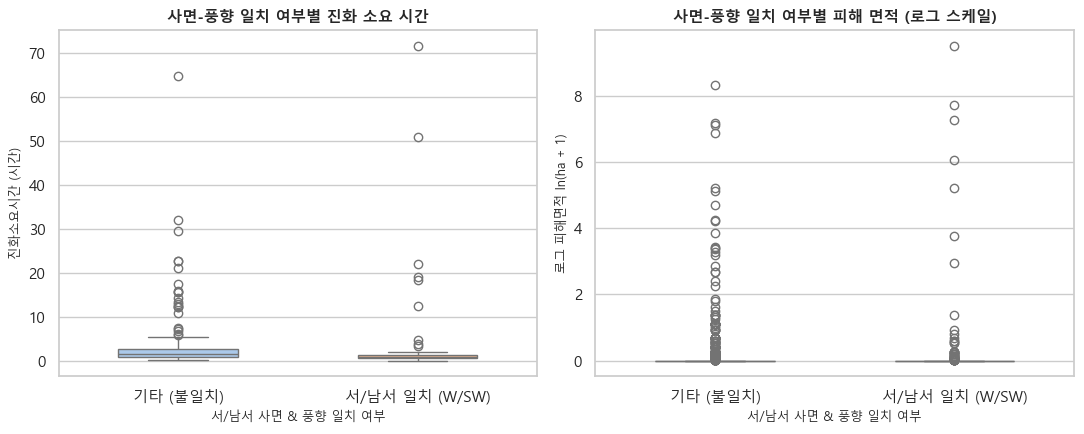

In [5]:
yd = gw[gw['is_yeongdong'] == True].copy()
yd['aspect_wind_match'] = yd['west_southwest_aspect'] & yd['west_southwest_wind']
yd['aspect_wind_match_label'] = yd['aspect_wind_match'].map({True: '서/남서 일치 (W/SW)', False: '기타 (불일치)'})

# 통계 요약
hyp2_stats = yd.groupby('aspect_wind_match', observed=False).agg(
    total_N=('fire_id', 'count'),
    valid_N=('_suppression_valid', 'sum'),
    mean_duration=('_suppression_hours', 'mean'),
    large_12h_rate=('_large_fire_12h', 'mean'),
    mean_damage=('_damage_ha', 'mean'),
    median_damage=('_damage_ha', 'median')
)
print(hyp2_stats)

# 시각화 (착시 효과 방지를 위해 order 고정)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
category_order = ['기타 (불일치)', '서/남서 일치 (W/SW)']

sns.boxplot(data=yd[yd['_suppression_valid']], x='aspect_wind_match_label', y='_suppression_hours', 
            ax=axes[0], palette='pastel', width=0.5, order=category_order, hue='aspect_wind_match_label', legend=False)
axes[0].set_title('사면-풍향 일치 여부별 진화 소요 시간', fontsize=11, fontweight='bold')
axes[0].set_xlabel('서/남서 사면 & 풍향 일치 여부', fontsize=9)
axes[0].set_ylabel('진화소요시간 (시간)', fontsize=9)

sns.boxplot(data=yd, x='aspect_wind_match_label', y='_log_damage_ha', 
            ax=axes[1], palette='pastel', width=0.5, order=category_order, hue='aspect_wind_match_label', legend=False)
axes[1].set_title('사면-풍향 일치 여부별 피해 면적 (로그 스케일)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('서/남서 사면 & 풍향 일치 여부', fontsize=9)
axes[1].set_ylabel('로그 피해면적 ln(ha + 1)', fontsize=9)

plt.tight_layout()
plt.show()



**가설 1.2 검증 결과 및 해석**:

영동권에서 서·남서 사면과 서·남서 풍향이 일치한 집단은 전체 371건, 진화소요시간 유효 표본 48건이었다. 이 집단의 평균 진화소요시간은 4.92시간, 12시간 이상 진화 비율은 12.50%, 평균 피해면적은 47.69ha였다. 반면 불일치 집단은 전체 1,238건, 유효 221건, 평균 진화소요시간 3.19시간, 12시간 이상 진화 비율 7.24%, 평균 피해면적 6.85ha였다.

즉, 영동권에서는 사면 방향과 풍향이 맞물릴 때 진화 지연과 피해면적 꼬리 위험이 함께 커진다. 다만 두 집단 모두 피해면적 중앙값은 0ha이고, 박스플롯의 중심부도 낮은 값에 몰려 있다. 따라서 이 결과는 일반적인 모든 산불의 피해가 커진다는 뜻이 아니라, 일부 대형 피해 사례가 평균을 끌어올리는 지형-기상 정렬 위험으로 해석해야 한다.


### 가설 1.3: 영동권 × 서/남서 사면 × 접근취약 × 기상 피크
- **가설**: 공간적 취약성(서/남서 사면 + 소방 인프라 접근취약)과 당일 기상 피크 조건(평균 풍속 >= 3m/s 또는 최소 상대습도 <= 30%)이 결합할 때, 피해면적과 진화 지연 위험이 함께 커지는가?


           total_N  valid_N  mean_duration  large_12h_rate  mean_damage  median_damage
combo_1.3                                                                             
False         1486      246       3.051152        0.073171    15.004004            0.0
True           123       23       8.283333        0.173913    31.519106            0.0


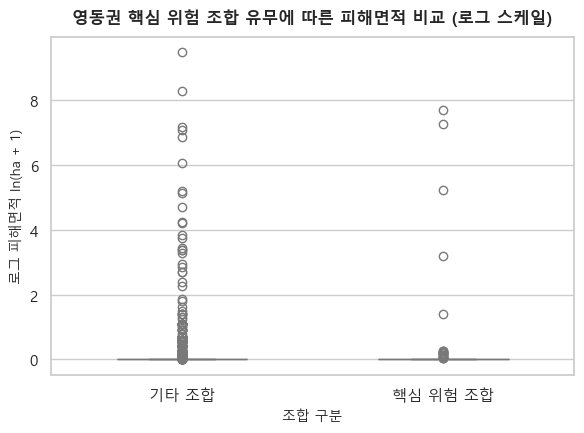

In [6]:
yd['weather_peak'] = (yd['wind_active'] >= 3.0) | (yd['humid_active'] <= 30.0)
yd['combo_1.3'] = yd['west_southwest_aspect'] & yd['access_vulnerable'] & yd['weather_peak']
yd['combo_label'] = yd['combo_1.3'].map({True: '핵심 위험 조합', False: '기타 조합'})

hyp3_stats = yd.groupby('combo_1.3', observed=False).agg(
    total_N=('fire_id', 'count'),
    valid_N=('_suppression_valid', 'sum'),
    mean_duration=('_suppression_hours', 'mean'),
    large_12h_rate=('_large_fire_12h', 'mean'),
    mean_damage=('_damage_ha', 'mean'),
    median_damage=('_damage_ha', 'median')
)
print(hyp3_stats)

# 시각화 (order 고정)
plt.figure(figsize=(6, 4.5))
combo_order = ['기타 조합', '핵심 위험 조합']
sns.boxplot(data=yd, x='combo_label', y='_log_damage_ha', palette='coolwarm', width=0.5, order=combo_order, hue='combo_label', legend=False)
plt.title('영동권 핵심 위험 조합 유무에 따른 피해면적 비교 (로그 스케일)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('조합 구분', fontsize=10)
plt.ylabel('로그 피해면적 ln(ha + 1)', fontsize=10)
plt.tight_layout()
plt.show()



**가설 1.3 검증 결과 및 해석**:

영동권에서 서·남서 사면, 접근 취약, 기상 피크가 동시에 충족된 핵심 위험 조합은 전체 123건, 진화소요시간 유효 표본 23건이었다. 이 집단의 평균 진화소요시간은 8.28시간, 12시간 이상 진화 비율은 17.39%, 평균 피해면적은 31.52ha였다. 기타 조합은 전체 1,486건, 유효 246건, 평균 진화소요시간 3.05시간, 12시간 이상 진화 비율 7.32%, 평균 피해면적 15.00ha였다.

핵심 위험 조합은 진화 지연과 장시간 진화 비율에서 뚜렷하게 불리하다. 다만 피해면적 분포를 보면 기타 조합에도 큰 이상치가 존재하고, 핵심 위험 조합의 유효 표본은 23건으로 작다. 따라서 이 조합은 고위험 후보 조건으로 반영하되, 단독으로 대형 피해를 결정한다고 해석하면 안 된다.


### 가설 1.4: 강풍 × 원격제어 불가능 (전국 단위)
- **가설**: 강풍 조건(평균 풍속 >= 3.0 m/s)에서 산불소화시설 원격제어가 불가능할 때, 진화 지연과 피해면적 꼬리 위험이 함께 커지는가?


                                  total_N  valid_N  mean_duration  large_12h_rate  mean_damage  median_damage
wind_peak_3ms remote_unavailable                                                                             
False         False                  6504     1889       2.000697        0.030704     0.387915            0.0
              True                  15213     3481       1.897819        0.026716     0.281229            0.0
True          False                   890      296       2.682658        0.067568     2.485685            0.0
              True                   2429      773       3.060271        0.069858    11.987769            0.0


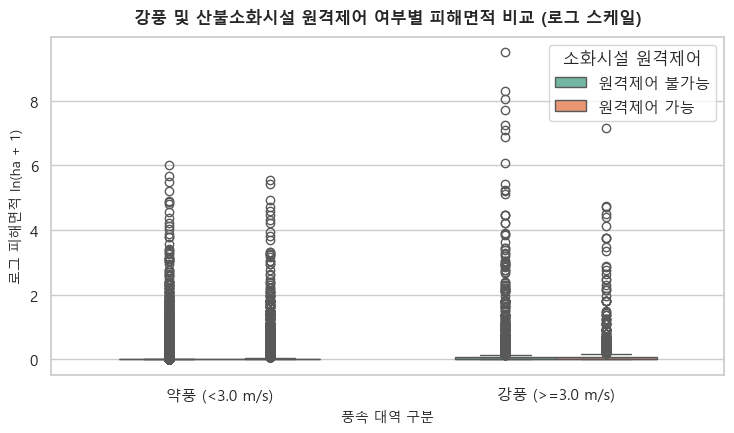

In [7]:
df_merged['wind_peak_3ms'] = df_merged['wind_active'] >= 3.0
df_merged['wind_label'] = df_merged['wind_peak_3ms'].map({True: '강풍 (>=3.0 m/s)', False: '약풍 (<3.0 m/s)'})
df_merged['remote_label'] = df_merged['remote_unavailable'].map({True: '원격제어 불가능', False: '원격제어 가능'})

# 통계 요약
hyp4_stats = df_merged.groupby(['wind_peak_3ms', 'remote_unavailable'], observed=False).agg(
    total_N=('fire_id', 'count'),
    valid_N=('_suppression_valid', 'sum'),
    mean_duration=('_suppression_hours', 'mean'),
    large_12h_rate=('_large_fire_12h', 'mean'),
    mean_damage=('_damage_ha', 'mean'),
    median_damage=('_damage_ha', 'median')
)
print(hyp4_stats)

# 시각화
plt.figure(figsize=(7.5, 4.5))
sns.boxplot(data=df_merged, x='wind_label', y='_log_damage_ha', hue='remote_label', palette='Set2', width=0.6)
plt.title('강풍 및 산불소화시설 원격제어 여부별 피해면적 비교 (로그 스케일)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('풍속 대역 구분', fontsize=10)
plt.ylabel('로그 피해면적 ln(ha + 1)', fontsize=10)
plt.legend(title='소화시설 원격제어')
plt.tight_layout()
plt.show()



**가설 1.4 검증 결과 및 해석**:

전국 단위에서 강풍 여부와 산불소화시설 원격제어 가능 여부를 함께 보면, 강풍 조건 자체가 먼저 위험을 높인다. 약풍 조건에서는 원격제어 가능 집단의 평균 진화소요시간이 2.00시간, 12시간 이상 진화 비율이 3.07%, 평균 피해면적이 0.39ha였고, 원격제어 불가능 집단은 평균 1.90시간, 2.67%, 0.28ha였다. 약풍에서는 원격제어 불가능 여부가 위험 증가로 일관되게 나타나지 않는다.

반면 강풍 조건에서는 원격제어 불가능 집단의 평균 피해면적이 11.99ha로 원격제어 가능 집단 2.49ha보다 크게 높고, 평균 진화소요시간도 3.06시간으로 원격제어 가능 집단 2.68시간보다 길다. 12시간 이상 진화 비율은 각각 6.99%와 6.76%로 거의 비슷하다.

따라서 이 결과는 원격제어 불가능 자체의 보편적 효과라기보다, 강풍 상황에서 원격제어 불가능 지역의 피해면적 꼬리가 커질 수 있다는 신호로 보는 것이 안전하다. 모든 집단의 피해면적 중앙값은 0ha이므로 평균 피해면적 해석에는 대형 피해 이상치 영향을 함께 고려해야 한다.


### 가설 1.5: 저습/실효습도 × 접근취약 (전국 단위)
- **가설**: 대기 수분 감쇄가 진행된 건조 상황(실효습도 <= 30.0%) 하에서 접근 인프라가 취약(access_burden 상위 33%)할 때, 건조로 인한 발화 용이성과 접근 장애가 상승작용을 일으켜 대형 산불 비율이 극대화되는가?



                                     total_N  valid_N  mean_duration  large_12h_rate  mean_damage  median_damage
humid_peak_30 access_vulnerable_nat                                                                             
False         False                     7481      825       1.625494        0.009697     0.034605            0.0
              True                      3384      481       2.287526        0.029106     0.094119            0.0
True          False                     9210     3356       2.031398        0.037843     2.855224            0.0
              True                      4961     1777       2.412833        0.042769     2.269280            0.0


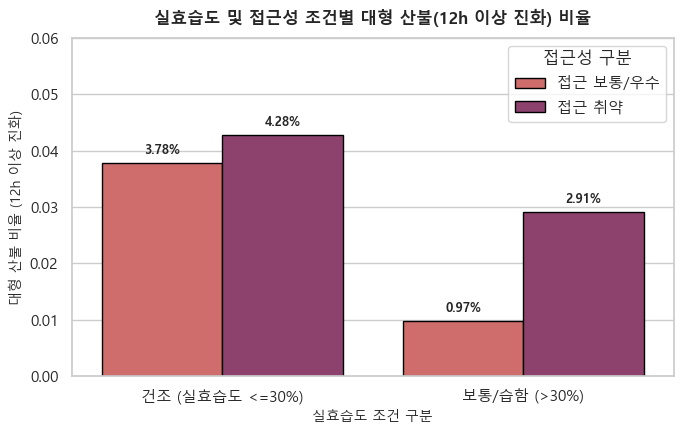

In [8]:
df_merged['humid_peak_30'] = df_merged['effective_humidity'] <= 30.0
df_merged['humid_label'] = df_merged['humid_peak_30'].map({True: '건조 (실효습도 <=30%)', False: '보통/습함 (>30%)'})
df_merged['access_label'] = df_merged['access_vulnerable_nat'].map({True: '접근 취약', False: '접근 보통/우수'})

# 통계 요약
hyp5_stats = df_merged.groupby(['humid_peak_30', 'access_vulnerable_nat'], observed=False).agg(
    total_N=('fire_id', 'count'),
    valid_N=('_suppression_valid', 'sum'),
    mean_duration=('_suppression_hours', 'mean'),
    large_12h_rate=('_large_fire_12h', 'mean'),
    mean_damage=('_damage_ha', 'mean'),
    median_damage=('_damage_ha', 'median')
)
print(hyp5_stats)

# 시각화
hyp5_plot_data = df_merged[df_merged['_suppression_valid']].groupby(['humid_label', 'access_label'], observed=False)['_large_fire_12h'].mean().reset_index()

plt.figure(figsize=(7, 4.5))
sns.barplot(data=hyp5_plot_data, x='humid_label', y='_large_fire_12h', hue='access_label', palette='flare', edgecolor='black')
plt.title('실효습도 및 접근성 조건별 대형 산불(12h 이상 진화) 비율', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('실효습도 조건 구분', fontsize=10)
plt.ylabel('대형 산불 비율 (12h 이상 진화)', fontsize=10)
plt.ylim(0, 0.06)

for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f"{h*100:.2f}%", (p.get_x() + p.get_width() / 2., h + 0.001),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold', fontsize=9)
plt.legend(title='접근성 구분')
plt.tight_layout()
plt.show()



**가설 1.5 검증 결과 및 해석**:

실효습도 30% 이하의 건조 조건에서는 전국 산불의 12시간 이상 진화 비율이 뚜렷하게 높다. 보통·습함 조건에서 접근 보통·우수 집단은 0.97%, 접근 취약 집단은 2.91%였고, 건조 조건에서는 접근 보통·우수 집단이 3.78%, 접근 취약 집단이 4.28%였다.

접근 취약성은 습한 조건과 건조 조건 모두에서 평균 진화소요시간을 늘리는 방향으로 나타난다. 보통·습함 조건에서는 접근 보통·우수 1.63시간, 접근 취약 2.29시간이고, 건조 조건에서는 접근 보통·우수 2.03시간, 접근 취약 2.41시간이다.

다만 평균 피해면적은 건조 조건에서 접근 보통·우수 집단 2.86ha, 접근 취약 집단 2.27ha로 접근 취약 쪽이 더 크지 않다. 따라서 이 가설은 '건조 + 접근 취약'이 장시간 진화 위험을 높인다는 근거로는 유효하지만, 피해면적까지 항상 최대화한다고 단정하기는 어렵다.


## 2. 날씨와 공간 결합 심화 EDA (Section 2)

기상 위험 인자와 물리 지형/공간 접근성을 함께 교차하여 기상-지형 융합 메커니즘을 분석합니다.



### 추가 EDA 2.1: 고도(Elevation) vs 대기 건조도 (VPD & 이슬점 격차)
- **분석**: 산림의 고도가 높을수록 실제 기온 저하와 기압 격차가 수반됩니다. 고도와 대기 건조도의 실질적 물리량 지표인 VPD 및 이슬점 격차의 상관관계가 강원특별자치도와 타 지역 간에 어떠한 공간적 편차를 보이는지 규명합니다.



유효 분석 표본 수 N: 25036
[기타] (N=20897)
  고도 vs VPD: correlation=0.0382, p-value=3.19e-08
  고도 vs 이슬점 격차: correlation=0.0349, p-value=4.50e-07
[강원] (N=4139)
  고도 vs VPD: correlation=-0.0387, p-value=1.29e-02
  고도 vs 이슬점 격차: correlation=-0.2484, p-value=3.16e-59


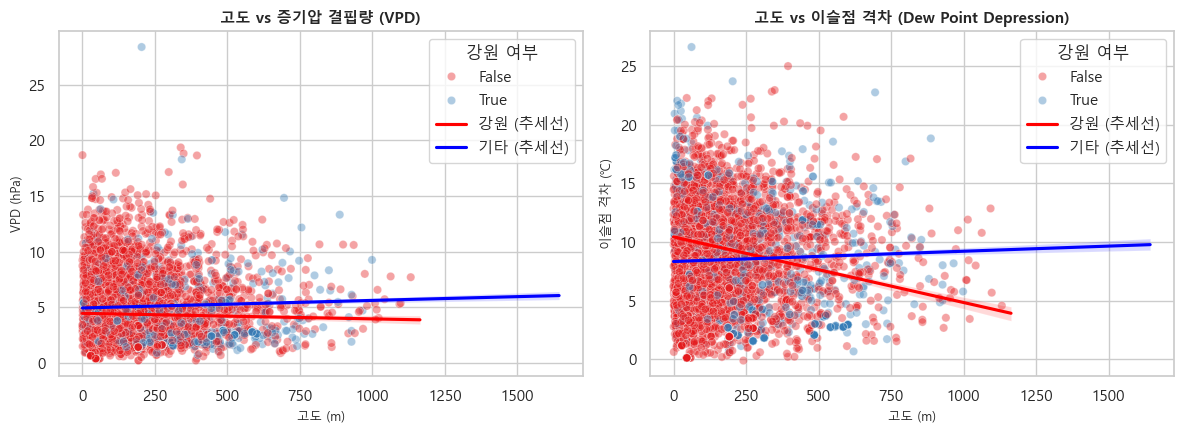

In [12]:
valid_elev_vpd = df_merged[['고도(m)', 'VPD', 'dew_gap', 'is_gangwon']].dropna()
print(f"유효 분석 표본 수 N: {len(valid_elev_vpd)}")

# 피어슨 상관계수
for group_name, group_df in valid_elev_vpd.groupby('is_gangwon'):
    label = "강원" if group_name else "기타"
    corr_vpd, p_vpd = stats.pearsonr(group_df['고도(m)'], group_df['VPD'])
    corr_dew, p_dew = stats.pearsonr(group_df['고도(m)'], group_df['dew_gap'])
    print(f"[{label}] (N={len(group_df)})")
    print(f"  고도 vs VPD: correlation={corr_vpd:.4f}, p-value={p_vpd:.2e}")
    print(f"  고도 vs 이슬점 격차: correlation={corr_dew:.4f}, p-value={p_dew:.2e}")

# 시각화 (샘플링 5000건 적용하여 시각적 중복 제거)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sample_df = df_merged.sample(n=min(len(df_merged), 5000), random_state=42)

sns.scatterplot(data=sample_df, x='고도(m)', y='VPD', hue='is_gangwon', alpha=0.4, ax=axes[0], palette='Set1')
sns.regplot(data=df_merged[df_merged['is_gangwon'] == True], x='고도(m)', y='VPD', scatter=False, ax=axes[0], label='강원 (추세선)', color='red')
sns.regplot(data=df_merged[df_merged['is_gangwon'] == False], x='고도(m)', y='VPD', scatter=False, ax=axes[0], label='기타 (추세선)', color='blue')
axes[0].set_title('고도 vs 증기압 결핍량 (VPD)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('고도 (m)', fontsize=9)
axes[0].set_ylabel('VPD (hPa)', fontsize=9)
axes[0].legend(title='강원 여부')

sns.scatterplot(data=sample_df, x='고도(m)', y='dew_gap', hue='is_gangwon', alpha=0.4, ax=axes[1], palette='Set1')
sns.regplot(data=df_merged[df_merged['is_gangwon'] == True], x='고도(m)', y='dew_gap', scatter=False, ax=axes[1], label='강원 (추세선)', color='red')
sns.regplot(data=df_merged[df_merged['is_gangwon'] == False], x='고도(m)', y='dew_gap', scatter=False, ax=axes[1], label='기타 (추세선)', color='blue')
axes[1].set_title('고도 vs 이슬점 격차 (Dew Point Depression)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('고도 (m)', fontsize=9)
axes[1].set_ylabel('이슬점 격차 (℃)', fontsize=9)
axes[1].legend(title='강원 여부')

plt.tight_layout()
plt.show()



**추가 EDA 2.1 결과 및 해석**:

고도와 대기 건조도 지표의 관계는 지역에 따라 다르지만, VPD와의 직접 상관은 전반적으로 약하다. 타 지역은 고도-VPD 상관계수 0.0382, p=3.19e-08로 통계적으로 유의한 양의 관계를 보였고, 고도-이슬점 격차도 0.0349, p=4.50e-07로 약한 양의 관계였다. 표본 수가 20,897건으로 크기 때문에 통계적 유의성에 비해 효과 크기는 작다.

강원도는 고도-VPD 상관계수 -0.0387, p=0.0129로 약한 음의 관계였고, 고도-이슬점 격차는 -0.2484, p=3.16e-59로 더 뚜렷한 음의 관계를 보였다. 즉, 강원도에서는 고도가 높아질수록 이슬점 격차가 줄어드는 경향이 나타나며, 저지대·해안권의 건조 신호가 더 강하게 보일 수 있다.

따라서 고도는 전국 공통의 단순 건조도 대리변수로 쓰기 어렵다. 모델링에서는 `고도` 단독 효과보다 강원 여부, 영동·영서 구분, 풍속·습도 지표와의 상호작용을 함께 검토해야 한다.


### 추가 EDA 2.2: 경사도(Slope) vs 평균 풍속
- **분석**: 산림의 경사도가 급할수록 국지적인 풍속 가속(Valley breeze 또는 기압 경도에 따른 기류 협곡 수렴) 효과가 동반되는지, 그리고 강원도 험준 지형의 공간적 독특성이 존재하는지 파악합니다.



유효 분석 표본 수 N: 25036
[기타] (N=20897)
  경사도 vs 풍속: correlation=0.0816, p-value=3.06e-32
[강원] (N=4139)
  경사도 vs 풍속: correlation=-0.0617, p-value=7.09e-05


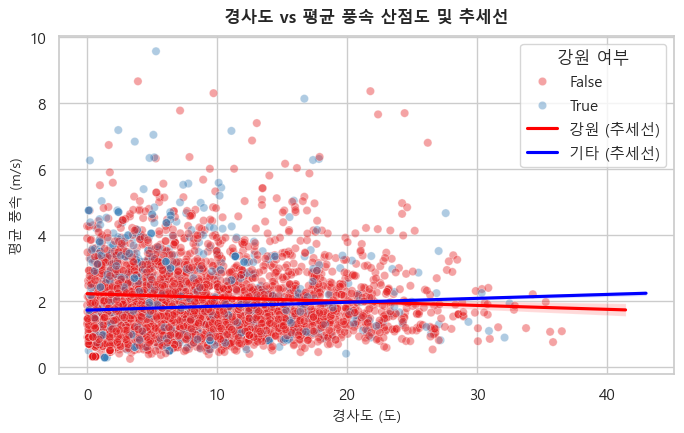

In [10]:
valid_slope_wind = df_merged[['경사도(도)', 'wind_active', 'is_gangwon']].dropna()
print(f"유효 분석 표본 수 N: {len(valid_slope_wind)}")

# 피어슨 상관계수
for group_name, group_df in valid_slope_wind.groupby('is_gangwon'):
    label = "강원" if group_name else "기타"
    corr, p = stats.pearsonr(group_df['경사도(도)'], group_df['wind_active'])
    print(f"[{label}] (N={len(group_df)})")
    print(f"  경사도 vs 풍속: correlation={corr:.4f}, p-value={p:.2e}")

# 시각화 (샘플링 5000건)
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=sample_df, x='경사도(도)', y='wind_active', hue='is_gangwon', alpha=0.4, palette='Set1')
sns.regplot(data=df_merged[df_merged['is_gangwon'] == True], x='경사도(도)', y='wind_active', scatter=False, label='강원 (추세선)', color='red')
sns.regplot(data=df_merged[df_merged['is_gangwon'] == False], x='경사도(도)', y='wind_active', scatter=False, label='기타 (추세선)', color='blue')
plt.title('경사도 vs 평균 풍속 산점도 및 추세선', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('경사도 (도)', fontsize=10)
plt.ylabel('평균 풍속 (m/s)', fontsize=10)
plt.legend(title='강원 여부')
plt.tight_layout()
plt.show()



**추가 EDA 2.2 결과 및 해석**:

경사도와 평균 풍속의 상관은 타 지역과 강원도에서 방향이 다르지만, 효과 크기는 모두 작다. 타 지역은 상관계수 0.0816, p=3.06e-32로 약한 양의 관계를 보였고, 강원도는 상관계수 -0.0617, p=7.09e-05로 약한 음의 관계를 보였다.

산점도에서도 두 지역 모두 점들이 넓게 퍼져 있어 경사도 하나만으로 풍속을 설명하기 어렵다. 타 지역에서는 경사가 가팔라질수록 풍속이 약간 커지는 통계적 경향이 있지만, 강원도에서는 급경사지보다 해안·협곡·완경사지의 국지 바람 조건이 더 중요하게 작동할 가능성이 있다.

따라서 경사도는 단독 위험 변수보다 지역 구분, 풍향, 고도, 영동권 여부와 결합해 해석하는 보조 지형 변수로 사용하는 편이 적절하다.


### 추가 EDA 2.3: 악기상 조건 × 접근 부담 시너지 효과 (강원도 기준)
- **분석**: 기상 피크 상황(평균 풍속 >= 3.0 m/s 또는 실효습도 <= 30.0%)이라는 최악의 기후 위해도가 닥쳤을 때, 소방 인프라 접근 장애(access_grade_gw)가 산불 진화 시간에 미치는 복합 증폭 효과를 히트맵으로 검증합니다.



                    평시 기상  기상 피크 (강풍/저습)
access_grade_gw                         
접근 우수            1.446491       2.442435
접근 보통            2.099405       2.064428
접근 취약            3.059722       3.541932


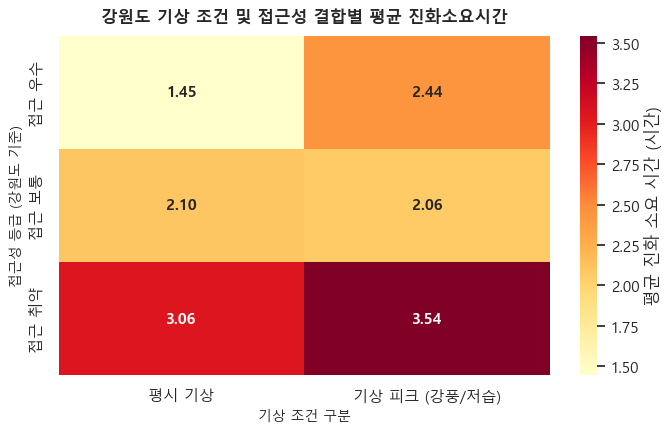

In [11]:
# 강원도 서브셋 기준 weather_peak 정의 및 히트맵 데이터 가공
gw['weather_peak'] = (gw['wind_active'] >= 3.0) | (gw['effective_humidity'] <= 30.0)
joint3_data = gw[gw['_suppression_valid']].groupby(['weather_peak', 'access_grade_gw'], observed=False)['_suppression_hours'].mean().unstack(level=0)
joint3_data.columns = ['평시 기상', '기상 피크 (강풍/저습)']

print(joint3_data)

# 시각화 (YlOrRd harmonized palette 사용)
plt.figure(figsize=(7, 4.5))
sns.heatmap(joint3_data, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': '평균 진화 소요 시간 (시간)'}, 
            annot_kws={'fontweight':'bold', 'size':11})
plt.title('강원도 기상 조건 및 접근성 결합별 평균 진화소요시간', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('기상 조건 구분', fontsize=10)
plt.ylabel('접근성 등급 (강원도 기준)', fontsize=10)
plt.tight_layout()
plt.show()



**추가 EDA 2.3 결과 및 해석**:

강원도 기준 접근성 등급과 기상 조건을 함께 보면, 접근 취약 집단의 평균 진화소요시간이 가장 길다. 평시 기상에서는 접근 우수 1.45시간, 접근 보통 2.10시간, 접근 취약 3.06시간이고, 기상 피크 조건에서는 접근 우수 2.44시간, 접근 보통 2.06시간, 접근 취약 3.54시간이다.

기상 피크는 접근 우수 집단과 접근 취약 집단에서 평균 진화소요시간을 높이지만, 접근 보통 집단에서는 거의 차이가 없다. 따라서 단순한 선형 상승이라기보다, 접근성 등급별로 기상 영향이 다르게 나타나는 상호작용으로 해석해야 한다.

가장 불리한 조합은 기상 피크 + 접근 취약이며, 가장 낮은 조합은 평시 기상 + 접근 우수다. 다만 이 분석은 유효 진화소요시간이 있는 표본의 조건부 평균 비교이므로, 실제 시설 개선이나 접근로 개선의 인과효과로 직접 해석해서는 안 된다.
